# EFFICIENTNET-B4 OPTIMIZED TRAINING FOR RETINAL DISEASE DETECTION (v5)

```
Hardware      : HP Omen 16 (RTX 4060 8GB, i7-13700HX)
Dataset       : RFMiD (3200 images, 46 diseases)
Optimizations : Mixed Precision (BF16), TF32, Optimised Data Loading
Tested on     : torch==2.1.0
```


---

## All Fixes Applied (v1 → v5)

| # | Problem | v1 | v2 | v3 | v4 | **v5** |
|---|---------|----|----|----|----|--------|
| 1 | Too many frozen blocks | features[0-6] (7/9) | features[0-3] (4/9) | features[0-3] | features[0-3] | **features[0-2]** ✅ |
| 2 | BatchNorm forced eval | Yes | Removed ✅ | Removed ✅ | Removed ✅ | Removed ✅ |
| 3 | Initial LR | 1e-4 | 3e-5 | 3e-5 | 3e-5 | **1e-5** ✅ |
| 4 | Early stopping patience | 5 | 8 | 10 | 10 | **15** ✅ |
| 5 | Monitoring threshold | 0.3 | 0.2 | 0.05 | 0.05 | **0.5** ✅ |
| 6 | Class weight explosion | uncapped | uncapped ❌ | capped at 10 | capped at 10 | **None → cap=5.0 at epoch 10** ✅ |
| 7 | LR warmup | None | None | None | None | **5 epochs** ✅ |
| 8 | Batch size | 32 | 32 | 32 | 32 | **16** ✅ |
| 9 | Pre-training diagnostic | None | None | Added ✅ | Added ✅ | Added ✅ |

---

## Backbone Freezing — Exact Breakdown

EfficientNet-B4 has 9 feature blocks (features[0] to features[8]) + classifier.

| Block | Role | Params (approx) | Frozen in v5? |
|-------|------|-----------------|---------------|
| features[0] | Stem conv — edges, corners | ~1.5K | ✅ YES |
| features[1] | MBConv1 — simple textures | ~6.6K | ✅ YES |
| features[2] | MBConv6 — low patterns | ~1.5M | ✅ YES |
| features[3] | MBConv6 — mid patterns | ~2.1M | ❌ NO |
| features[4] | MBConv6 — complex patterns | ~3.5M | ❌ NO |
| features[5] | MBConv6 — high semantics | ~4.2M | ❌ NO |
| features[6] | MBConv6 — high semantics | ~8.7M | ❌ NO |
| features[7] | MBConv6 — high semantics | ~14.9M | ❌ NO |
| features[8] | Head conv — abstract features | ~1.8M | ❌ NO |
| classifier | Custom head (our layers) | ~0.6M | ❌ NO (always trainable) |

**Frozen phase (epochs 1-10)**: features[0-2] frozen (~3.6M params), features[3-8] + classifier trainable (~33.4M params)

**Fine-tune phase (epoch 11+)**: ALL layers trainable

---

## Comparison with ResNet-50 — Fairness Justification

| Aspect | ResNet-50 | EfficientNet-B4 (v5) | Fair? |
|--------|-----------|---------------------|-------|
| Dataset splits | Same | Same | ✅ |
| Loss function (train) | Weighted BCE | Unweighted → Weighted (cap=5.0) | ✅ |
| Loss function (val) | Unweighted BCE | Unweighted BCE | ✅ |
| Augmentation | HFlip + VFlip + Rotation + ColorJitter | Same | ✅ |
| Optimizer | AdamW (weight_decay=0.01) | Same | ✅ |
| Fine-tune LR | 1e-5 | 1e-5 | ✅ |
| Unfreeze epoch | 10 | 10 | ✅ |
| Early stopping metric | F1 macro | Same | ✅ |
| Threshold tuning | Grid search on val set | Same | ✅ |
| Input size | 224×224 | 380×380 | ✅ Architecture-appropriate |
| Frozen layers | layer1-3 (~35% of params) | features[0-2] (~10% of params) | ✅ Architecture-appropriate |
| Initial LR | 1e-4 | 1e-5 | ✅ Architecture-appropriate |
| Batch size | 32 | 16 | ✅ Architecture-appropriate |
| LR warmup | None | 5 epochs | ✅ Helps B4 stabilize |
| Class weight strategy | Full weights from start | None → cap=5.0 at epoch 10 | ✅ Prevents early collapse |

---

## Expected Training Progress

| Epoch | Phase | Expected F1 Macro |
|-------|-------|-------------------|
| 1-5 | Warmup + Frozen | 0.05 → 0.10 |
| 6-10 | Frozen | 0.10 → 0.20 |
| 11-15 | Unfrozen + Weights | 0.20 → 0.35 |
| 16-30 | Fine-tune | 0.35 → 0.45+ |

---

## Key v5 Improvements Summary

| Fix | Why It Matters |
|-----|----------------|
| **LR = 1e-5** | Matches ResNet-50's fine-tune LR; prevents gradient explosion |
| **Batch size = 16** | B4 at 380×380 needs smaller batches on 8GB VRAM |
| **Warmup (5 epochs)** | Gradual LR ramp prevents early instability |
| **features[0-2] frozen** | Allows mid-level features to adapt to retinal domain |
| **No class weights initially** | Prevents model from learning "predict all zeros" |
| **Cap=5.0 after epoch 10** | Corrects imbalance without loss gaming |
| **Monitoring threshold = 0.5** | Standard threshold for meaningful F1 during training |
| **Patience = 15** | Gives B4 time to stabilize before early stopping |

---

## Training Configuration Summary

```python
# Hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
NUM_EPOCHS = 50
UNFREEZE_EPOCH = 10
WARMUP_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 15
PRED_THRESHOLD = 0.5

# Architecture
INPUT_SIZE = 380
FROZEN_BLOCKS = features[0-2]  # 3 blocks
CLASSIFIER = Dropout(0.3) → Linear(1792,512) → ReLU → Dropout(0.3) → Linear(512,46)

# Loss Strategy
# Epochs 1-10:  BCEWithLogitsLoss()  (unweighted)
# Epochs 11-50: BCEWithLogitsLoss(pos_weight=capped_weights)  (cap=5.0)

# Optimizer
OPTIMIZER = AdamW(lr=1e-5, weight_decay=0.01, betas=(0.9, 0.999))

# Scheduler
# Epochs 1-5:   LinearLR(start_factor=0.1, end_factor=1.0, total_iters=5)
# Epochs 6-50:  CosineAnnealingLR(T_max=50, eta_min=1e-6)

## 1. Imports

In [1]:
import os, gc, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

_pt_ver = tuple(int(x) for x in torch.__version__.split('.')[:2])
if _pt_ver >= (2, 3):
    from torch.amp import autocast, GradScaler
    def make_scaler(): return GradScaler('cuda')
else:
    from torch.cuda.amp import autocast, GradScaler
    def make_scaler(): return GradScaler()

from sklearn.metrics import f1_score, precision_recall_fscore_support

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

PyTorch version : 2.1.0+cu121
CUDA available  : True


## 2. Hardware Optimization (RTX 4060 Specific)

In [2]:
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"BF16 support   : {torch.cuda.is_bf16_supported()}")
a = torch.randn(1000, 1000, device='cuda')
b = torch.randn(1000, 1000, device='cuda')
c = a @ b
print(f"GPU tensor test: PASSED (result shape: {c.shape})")

PyTorch        : 2.1.0+cu121
CUDA available : True
GPU            : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM           : 8.59 GB
BF16 support   : True
GPU tensor test: PASSED (result shape: torch.Size([1000, 1000]))


In [3]:
class HardwareOptimizer:
    """Optimise for HP Omen 16 RTX 4060."""
    def __init__(self):
        self.device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.gpu_name     = 'N/A'
        self.vram_total   = 0.0
        self.cuda_version = 'N/A'
        self.use_bf16     = False
        if self.device.type == 'cuda':
            self.gpu_name     = torch.cuda.get_device_name(0)
            self.vram_total   = torch.cuda.get_device_properties(0).total_memory / 1e9
            self.cuda_version = torch.version.cuda
            torch.backends.cudnn.benchmark        = True
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32        = True
            self.use_bf16 = torch.cuda.is_bf16_supported()

    def print_specs(self):
        print('=' * 60)
        print('HP Omen 16 Hardware Configuration')
        print('=' * 60)
        print('CPU: Intel i7-13700HX (16 cores)')
        print(f'GPU: {self.gpu_name}')
        if self.device.type == 'cuda':
            print(f'VRAM         : {self.vram_total:.1f} GB')
            print(f'CUDA         : {self.cuda_version}')
            print(f'BF16 Support : {self.use_bf16}')
            print('TF32 Enabled : True')
        print('=' * 60)

hw       = HardwareOptimizer()
hw.print_specs()
device   = hw.device
use_bf16 = hw.use_bf16

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

HP Omen 16 Hardware Configuration
CPU: Intel i7-13700HX (16 cores)
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.6 GB
CUDA         : 12.1
BF16 Support : True
TF32 Enabled : True


## 3. Optimized Dataset Class *(Identical to ResNet-50 — no changes for fair comparison)*

In [4]:
class OptimizedRFMiDDataset(Dataset):
    """Memory-efficient dataset with PIL loading."""
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir       = img_dir
        self.labels_df     = labels_df.reset_index(drop=True)
        self.transform     = transform
        self.disease_cols  = [c for c in labels_df.columns if c != 'ID']
        self.num_classes   = len(self.disease_cols)
        self.img_paths     = []
        self.valid_indices = []
        for idx, img_name in enumerate(self.labels_df['ID'].values):
            base  = os.path.join(img_dir, str(img_name))
            found = False
            for ext in ['', '.png', '.jpg', '.jpeg']:
                if os.path.exists(base + ext):
                    self.img_paths.append(base + ext)
                    self.valid_indices.append(idx)
                    found = True
                    break
            if not found:
                print(f'Warning: image not found -> {img_name}')
                self.img_paths.append(None)
                self.valid_indices.append(idx)
        print(f'Loaded {len(self.valid_indices)} images from {img_dir}')

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        if p and os.path.exists(p):
            try:
                image = Image.open(p).convert('RGB')
            except Exception:
                image = Image.new('RGB', (380, 380), 'black')
        else:
            image = Image.new('RGB', (380, 380), 'black')
        if self.transform:
            image = self.transform(image)
        orig = self.valid_indices[idx]
        lbl  = self.labels_df.iloc[orig][self.disease_cols].values.astype(np.float32)
        return image, torch.tensor(lbl, dtype=torch.float32)

    def get_class_weights(self):
        counts = self.labels_df[self.disease_cols].sum().values
        w = len(self.labels_df) / (self.num_classes * (counts + 1e-6))
        return torch.tensor(w, dtype=torch.float32)

## 4. Optimized Transforms

EfficientNetB4 native input resolution is **380×380** (vs 224×224 for ResNet-50).
This is architecturally correct — both models receive their optimal input size.

In [5]:
INPUT_SIZE = 380  # EfficientNetB4 native resolution (vs 224 for ResNet-50)

class OptimizedTransforms:
    _MEAN = [0.485, 0.456, 0.406]  # Same ImageNet stats as ResNet-50
    _STD  = [0.229, 0.224, 0.225]

    @classmethod
    def get_train_transform(cls, sz=INPUT_SIZE):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])

    @classmethod
    def get_val_transform(cls, sz=INPUT_SIZE):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])

print(f'EfficientNetB4 input size : {INPUT_SIZE}x{INPUT_SIZE}')
print('Train augmentation        : HFlip + VFlip + Rotation + ColorJitter (same as ResNet-50)')

EfficientNetB4 input size : 380x380
Train augmentation        : HFlip + VFlip + Rotation + ColorJitter (same as ResNet-50)


## 5. Load Dataset

In [6]:
import os
os.chdir(r'D:\OcuSight')

DATA_DIR     = 'data/rfmid'
TRAIN_IMAGES = os.path.join(DATA_DIR, 'images', 'train')
VAL_IMAGES   = os.path.join(DATA_DIR, 'images', 'val')
TEST_IMAGES  = os.path.join(DATA_DIR, 'images', 'test')
TRAIN_LABELS = os.path.join(DATA_DIR, 'labels', 'train_labels.csv')
VAL_LABELS   = os.path.join(DATA_DIR, 'labels', 'val_labels.csv')
TEST_LABELS  = os.path.join(DATA_DIR, 'labels', 'test_labels.csv')

print(f'Working dir: {os.getcwd()}')
train_df = pd.read_csv(TRAIN_LABELS)
val_df   = pd.read_csv(VAL_LABELS)
test_df  = pd.read_csv(TEST_LABELS)
print(f'Training   : {len(train_df)} samples')
print(f'Validation : {len(val_df)} samples')
print(f'Testing    : {len(test_df)} samples')

disease_cols = [c for c in train_df.columns if c != 'ID']
num_classes  = len(disease_cols)
print(f'Disease classes: {num_classes}')

train_dataset = OptimizedRFMiDDataset(TRAIN_IMAGES, train_df, OptimizedTransforms.get_train_transform())
val_dataset   = OptimizedRFMiDDataset(VAL_IMAGES,   val_df,   OptimizedTransforms.get_val_transform())
test_dataset  = OptimizedRFMiDDataset(TEST_IMAGES,  test_df,  OptimizedTransforms.get_val_transform())

Working dir: D:\OcuSight
Training   : 1920 samples
Validation : 640 samples
Testing    : 640 samples
Disease classes: 46
Loaded 1920 images from data/rfmid\images\train
Loaded 640 images from data/rfmid\images\val
Loaded 640 images from data/rfmid\images\test


## 6. Optimized DataLoaders

In [7]:
BATCH_SIZE      = 16   # B4 @ 380×380 needs smaller batches on 8GB VRAM
NUM_WORKERS     = 0
PIN_MEMORY      = True
PREFETCH_FACTOR = None

_kw = dict(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, prefetch_factor=PREFETCH_FACTOR,
    persistent_workers=False,
)
train_loader = DataLoader(train_dataset, shuffle=True,  **_kw)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_kw)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_kw)

print(f'Batch size    : {BATCH_SIZE}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Batch size    : 16
Train batches : 120
Val batches   : 40
Test batches  : 40


## 7. Build EfficientNet-B4 Model

### Backbone Freezing Strategy

EfficientNet-B4 has 9 feature blocks (features[0–8]). We freeze only **features[0–2]**:

- **features[0–2] FROZEN** (~3.6M params, ~10% of total): stem + early MBConv blocks that
  detect edges, corners, and low-level textures. These transfer perfectly from ImageNet
  and do not need retraining for retinal images.
- **features[4–8] TRAINABLE** (~33.4M params, ~90% of total): later MBConv blocks that
  detect high-level semantics. These MUST adapt from ImageNet objects → retinal pathology.
- **classifier ALWAYS TRAINABLE**: our custom head.

This is analogous to ResNet-50 where layer1–3 are frozen (~35% of params) and layer4
is trainable. The principle is the same — freeze generic low-level features, train
high-level semantic features.

**BatchNorm is kept in train mode during freezing** — this lets running stats adapt
from ImageNet distribution to retinal fundus image distribution. Forcing BN into
eval() during fine-tuning was a key cause of F1=0 in v1.

In [8]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import EfficientNet_B4_Weights

torch.hub.set_dir(r'C:\temp_torch_cache')  # change path if needed

def build_efficientnet_b4(num_classes: int) -> nn.Module:
    """Build EfficientNetB4 with identical custom head to ResNet-50."""
    try:
        model = models.efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
    except RuntimeError:
        print("Weight corruption detected. Re-downloading...")
        cache_path = os.path.expanduser(r'~\.cache\torch\hub\checkpoints')
        if os.path.exists(cache_path):
            for f in os.listdir(cache_path):
                if "efficientnet_b4" in f:
                    os.remove(os.path.join(cache_path, f))
                    print(f"Removed: {f}")
        model = models.efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)

    nf = model.classifier[-1].in_features
    # Same head structure as ResNet-50 for fair comparison
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(nf, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model


def freeze_backbone(model, freeze=True):
    """
    Freeze features[0-2] only (3 out of 9 blocks) — fewer frozen blocks.

    WHY features[0-3]:
      - These blocks detect low-level features (edges, textures, simple patterns)
        that transfer well from ImageNet to any image domain including retinal.
      - features[4-8] detect high-level semantics and MUST adapt to retinal pathology.

    WHY NOT freeze BatchNorm:
      - Retinal fundus images have very different pixel distribution vs ImageNet.
      - Keeping BN in train mode lets running mean/var adapt to the new domain.
      - Forcing BN.eval() (as in v1) was a key cause of the output collapse / F1=0.
    """
    for i in range(3):  # features[0], [1], [2] only — fewer frozen blocks
        for param in model.features[i].parameters():
            param.requires_grad = not freeze
    # NOTE: No BatchNorm.eval() call here — intentional

    status = 'FROZEN' if freeze else 'UNFROZEN'
    print(f'EfficientNetB4 features[0-2]: {status}')
    if freeze:
        frozen_p    = sum(p.numel() for i in range(3) for p in model.features[i].parameters())
        trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Frozen params    : {frozen_p:,}  (~{frozen_p/sum(p.numel() for p in model.parameters())*100:.0f}% of total)')
        print(f'  Trainable params : {trainable_p:,}  (~{trainable_p/sum(p.numel() for p in model.parameters())*100:.0f}% of total)')


print('Building EfficientNet-B4...')
model = build_efficientnet_b4(num_classes).to(device)
freeze_backbone(model, freeze=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Model size           : {total_params * 4 / 1024 / 1024:.2f} MB')

Building EfficientNet-B4...
EfficientNetB4 features[0-2]: FROZEN
  Frozen params    : 71,776  (~0% of total)
  Trainable params : 18,418,454  (~100% of total)

Total parameters     : 18,490,230
Trainable parameters : 18,418,454
Model size           : 70.53 MB


## 7b. Pre-Training Diagnostic

**Run this before training.** Checks that sigmoid outputs are not already collapsed.
If max output < 0.05, the model is in a degenerate state before training even starts.

In [9]:
# ── Class weight diagnostic ──────────────────────────────────────────────────
raw_weights = train_dataset.get_class_weights()
print('Class weight stats (RAW):')
print(f'  min  : {raw_weights.min():.2f}')
print(f'  max  : {raw_weights.max():.2f}')
print(f'  mean : {raw_weights.mean():.2f}')
print(f'  weights > 50  : {(raw_weights > 50).sum().item()} classes')
print(f'  weights > 100 : {(raw_weights > 100).sum().item()} classes')
print()

# FIX v3: cap weights at 10.0
# Root cause of output collapse in v2: some rare classes had weights in the hundreds.
# With pos_weight=300 for a class appearing in 6 images, the model learns that
# predicting 0 for everything gives near-zero loss (since 99.9% of labels are 0).
# Capping at 10 preserves class imbalance correction while preventing loss gaming.
class_weights = torch.clamp(raw_weights, min=1.0, max=10.0).to(device)
print('Class weight stats (CAPPED at 10.0):')
print(f'  min  : {class_weights.min():.2f}')
print(f'  max  : {class_weights.max():.2f}')
print(f'  mean : {class_weights.mean():.2f}')
print()

# ── Sigmoid output diagnostic ─────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    imgs, _ = next(iter(val_loader))
    imgs = imgs.to(device)
    with autocast(dtype=amp_dtype if 'amp_dtype' in dir() else torch.bfloat16):
        probs = torch.sigmoid(model(imgs))

print('Sigmoid output stats (untrained model — should NOT be all near-zero):')
print(f'  min    : {probs.min():.4f}')
print(f'  max    : {probs.max():.4f}')
print(f'  mean   : {probs.mean():.4f}')
print(f'  > 0.05 : {(probs > 0.05).float().mean():.4f}  (fraction of outputs above 0.05)')
print(f'  > 0.10 : {(probs > 0.10).float().mean():.4f}  (fraction of outputs above 0.10)')
print()
if probs.max() < 0.05:
    print('WARNING: outputs already collapsed — model may not train. Check weights/architecture.')
else:
    print('OK: outputs are spread — model is in a healthy initial state.')

Class weight stats (RAW):
  min  : 0.03
  max  : 41739132.00
  mean : 1814755.25
  weights > 50  : 2 classes
  weights > 100 : 2 classes

Class weight stats (CAPPED at 10.0):
  min  : 1.00
  max  : 10.00
  mean : 5.30

Sigmoid output stats (untrained model — should NOT be all near-zero):
  min    : 0.4766
  max    : 0.5195
  mean   : 0.5000
  > 0.05 : 1.0000  (fraction of outputs above 0.05)
  > 0.10 : 1.0000  (fraction of outputs above 0.10)

OK: outputs are spread — model is in a healthy initial state.


## 8. Training Components

### Changes from v2/v3/v4 and why:

**Class weight cap (NEW in v3 — most important fix)**
The root cause of F1=0 in epochs 2+ was uncapped class weights. Some rare diseases
appear in only 1-6 training images, giving them pos_weight values of 100-500+.
With such extreme weights, the model learns that predicting zero for everything
minimises BCE loss perfectly (since 99%+ of labels are 0). Capping at 10.0
still corrects for class imbalance without allowing the model to game the loss.

**PRED_THRESHOLD = 0.05 (was 0.2)**
Monitoring threshold only — does not affect checkpoint saving or final evaluation.
Lowered because with capped weights the model's sigmoid outputs will be more
conservative (lower probabilities), so we need a lower threshold to detect any
learning signal during training.

**EARLY_STOPPING_PATIENCE = 10 (was 8)**
Extra buffer since the first few epochs may still show low F1 while the model
adapts BatchNorm stats to retinal images.

In [10]:
# Loss functions
# train_criterion: no pos_weight for first UNFREEZE_EPOCH epochs, then cap=5.0
# val_criterion is unweighted — same as ResNet-50
# FIX v4: start with NO class weights; add back (cap=5.0) after UNFREEZE_EPOCH
train_criterion = nn.BCEWithLogitsLoss()  # no pos_weight — avoids collapse in early epochs
val_criterion   = nn.BCEWithLogitsLoss()  # NO pos_weight — prevents val loss explosion

# Optimizer — same type and weight decay as ResNet-50
# LR is 3e-5 (vs 1e-4 for ResNet-50) because EfficientNet is more LR-sensitive
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,           # match ResNet-50 fine-tune LR (was 3e-5 — too high)
    weight_decay=0.01, # same as ResNet-50
    betas=(0.9, 0.999) # same as ResNet-50
)

NUM_EPOCHS     = 50
UNFREEZE_EPOCH = 10   # same as ResNet-50

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)


# FIX v4: LR warmup — ramp from 10% of base LR over 5 epochs
from torch.optim.lr_scheduler import LinearLR, SequentialLR
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
scaler    = None if use_bf16 else make_scaler()

# Monitoring threshold — only used during training loop to detect learning signal
# NOT used for checkpoint saving (that uses F1 macro) or final evaluation (grid-searched)
PRED_THRESHOLD = 0.5   # FIX v4: standard threshold for monitoring (was 0.05)

EARLY_STOPPING_PATIENCE = 15  # FIX v4: less aggressive — was 10, B4 needs longer to stabilise
epochs_no_improve = 0

print(f'Precision              : {"BF16" if use_bf16 else "FP16"}')
print(f'LR (frozen phase)      : 1e-5  (matches ResNet-50 fine-tune LR)')
print(f'LR (finetune phase)    : 1e-5  (same as ResNet-50)')
print(f'LR warmup              : 5 epochs, start_factor=0.1  (FIX v4)')
print(f'Weight decay           : 0.01  (same as ResNet-50)')
print(f'Epochs                 : {NUM_EPOCHS} (with early stopping)')
print(f'Unfreeze epoch         : {UNFREEZE_EPOCH}  (same as ResNet-50)')
print(f'Monitoring threshold   : {PRED_THRESHOLD}  (FIX v4: standard 0.5)')
print(f'Class weight cap       : None initially → 5.0 after epoch {UNFREEZE_EPOCH}  (FIX v4)')
print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE}  (FIX v4: was 10 — less aggressive)')
print(f'Val criterion          : BCEWithLogitsLoss NO pos_weight (same as ResNet-50)')

Precision              : BF16
LR (frozen phase)      : 1e-5  (matches ResNet-50 fine-tune LR)
LR (finetune phase)    : 1e-5  (same as ResNet-50)
LR warmup              : 5 epochs, start_factor=0.1  (FIX v4)
Weight decay           : 0.01  (same as ResNet-50)
Epochs                 : 50 (with early stopping)
Unfreeze epoch         : 10  (same as ResNet-50)
Monitoring threshold   : 0.5  (FIX v4: standard 0.5)
Class weight cap       : None initially → 5.0 after epoch 10  (FIX v4)
Early stopping patience: 15  (FIX v4: was 10 — less aggressive)
Val criterion          : BCEWithLogitsLoss NO pos_weight (same as ResNet-50)


## 9. Training Functions *(Identical to ResNet-50 notebook)*

In [11]:
def train_epoch(model, loader, criterion, optimizer, scaler, device, amp_dtype):
    model.train()
    total_loss, n = 0.0, 0
    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=amp_dtype):
            outputs = model(images)
            loss = criterion(outputs, labels)
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)


def validate_epoch(model, loader, criterion, device, amp_dtype, threshold=0.05):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, labels)
            total_loss += loss.item()
            n += 1
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float().cpu()
            all_preds.append(preds)
            all_labels.append(labels.cpu())
    if len(all_preds) == 0:
        return {'loss': 0.0, 'exact_match_acc': 0.0, 'per_label_acc': 0.0,
                'f1_macro': 0.0, 'f1_micro': 0.0, 'predictions': None, 'labels': None}
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    exact_match_acc = float(np.mean(np.all(preds == labels, axis=1)))
    per_label_acc   = float(np.mean(preds == labels))
    return {
        'loss'           : total_loss / max(n, 1),
        'exact_match_acc': exact_match_acc,
        'per_label_acc'  : per_label_acc,
        'f1_macro'       : f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro'       : f1_score(labels, preds, average='micro', zero_division=0),
        'predictions'    : preds,
        'labels'         : labels,
    }

## 10. Training Loop

In [12]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs',     exist_ok=True)

history = {
    'train_loss' : [], 'val_loss'      : [],
    'val_exact_acc': [], 'val_label_acc': [],
    'val_f1_macro' : [], 'val_f1_micro' : [],
    'lr'           : [],
}

best_f1    = 0.0
best_epoch = 0
EARLY_STOPPING_PATIENCE = 10
epochs_no_improve = 0
MIN_DELTA = 0.001  # same as ResNet-50

print('=' * 60)
print('STARTING EFFICIENTNET-B4 TRAINING (v5)')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    if epoch == UNFREEZE_EPOCH:
        freeze_backbone(model, freeze=False)
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-5,  # same fine-tune LR as ResNet-50
            weight_decay=0.01, betas=(0.9, 0.999)
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH, eta_min=1e-6
        )
        # FIX v4: add class weights (cap=5.0) once backbone is unfrozen
        capped_weights = torch.clamp(train_dataset.get_class_weights(), max=5.0).to(device)
        train_criterion = nn.BCEWithLogitsLoss(pos_weight=capped_weights)
        # Reset warmup: already past warmup phase, reinit cosine from epoch 0 of fine-tune
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH, eta_min=1e-6
        )
        print(f'  [Epoch {epoch+1}] Backbone unfrozen — full fine-tune (lr=1e-5)')
        print(f'  [Epoch {epoch+1}] Class weights (cap=5.0) re-enabled for fine-tune phase')

    train_loss  = train_epoch(model, train_loader, train_criterion, optimizer, scaler, device, amp_dtype)
    val_metrics = validate_epoch(model, val_loader, val_criterion, device, amp_dtype, threshold=PRED_THRESHOLD)

    # FIX v4: warmup for first 5 epochs, then cosine
    if epoch < 5:
        warmup_scheduler.step()
    else:
        scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_exact_acc'].append(val_metrics['exact_match_acc'])
    history['val_label_acc'].append(val_metrics['per_label_acc'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_micro'].append(val_metrics['f1_micro'])
    history['lr'].append(current_lr)

    if val_metrics['f1_macro'] > best_f1 + MIN_DELTA:
        best_f1    = val_metrics['f1_macro']
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_f1': best_f1, 'val_loss': val_metrics['loss'],
            'threshold': PRED_THRESHOLD,
        }, 'checkpoints/best_efficientnetb4.pth')
        is_best = True
    else:
        epochs_no_improve += 1
        is_best = False

    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 40)
    print(f'  Train Loss     : {train_loss:.4f}')
    print(f'  Val Loss       : {val_metrics["loss"]:.4f}')
    print(f'  Val Exact Acc  : {val_metrics["exact_match_acc"]:.4f}')
    print(f'  Val Label Acc  : {val_metrics["per_label_acc"]:.4f}')
    print(f'  Val F1 macro   : {val_metrics["f1_macro"]:.4f}')
    print(f'  Val F1 micro   : {val_metrics["f1_micro"]:.4f}')
    print(f'  LR             : {current_lr:.2e}')
    print(f'  Time           : {elapsed:.1f}s')
    if is_best:
        print(f'  *** New best F1 macro: {best_f1:.4f} (saved checkpoint) ***')

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch+1}')
        break

print(f'\n{"=" * 60}')
print(f'Training complete. Best Val F1 macro: {best_f1:.4f} at epoch {best_epoch}')
print('=' * 60)

STARTING EFFICIENTNET-B4 TRAINING (v5)



Epoch 1/50
----------------------------------------
  Train Loss     : 0.6941
  Val Loss       : 0.6924
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.5959
  Val F1 macro   : 0.0394
  Val F1 micro   : 0.0614
  LR             : 2.80e-06
  Time           : 222.7s
  *** New best F1 macro: 0.0394 (saved checkpoint) ***



Epoch 2/50
----------------------------------------
  Train Loss     : 0.6888
  Val Loss       : 0.6848
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.7497
  Val F1 macro   : 0.0325
  Val F1 micro   : 0.0806
  LR             : 4.60e-06
  Time           : 224.4s



Epoch 3/50
----------------------------------------
  Train Loss     : 0.6509
  Val Loss       : 0.5994
  Val Exact Acc  : 0.0063
  Val Label Acc  : 0.9657
  Val F1 macro   : 0.0185
  Val F1 micro   : 0.4818
  LR             : 6.40e-06
  Time           : 227.7s



Epoch 4/50
----------------------------------------
  Train Loss     : 0.3379
  Val Loss       : 0.1757
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.9719
  Val F1 macro   : 0.0192
  Val F1 micro   : 0.5503
  LR             : 8.20e-06
  Time           : 224.6s


...


Epoch 7/50
----------------------------------------
  Train Loss     : 0.1049
  Val Loss       : 0.0978
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.9719
  Val F1 macro   : 0.0192
  Val F1 micro   : 0.5503
  LR             : 9.96e-06
  Time           : 224.2s



Epoch 8/50
----------------------------------------
  Train Loss     : 0.1037
  Val Loss       : 0.0969
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.9719
  Val F1 macro   : 0.0192
  Val F1 micro   : 0.5503
  LR             : 9.92e-06
  Time           : 223.5s



Epoch 9/50
----------------------------------------
  Train Loss     : 0.1021
  Val Loss       : 0.0962
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.9719
  Val F1 macro   : 0.0192
  Val F1 micro   : 0.5503
  LR             : 9.86e-06
  Time           : 223.7s



Epoch 10/50
----------------------------------------
  Train Loss     : 0.1016
  Val Loss       : 0.0948
  Val Exact Acc  : 0.0000
  Val Label Acc  : 0.9719
  Val F1 macro   : 0.0192
  Val F1 micro   : 0.5503
  LR             : 9.78e-06
  Time           : 245.3s
EfficientNetB4 features[0-2]: UNFROZEN
  [Epoch 11] Backbone unfrozen — full fine-tune (lr=1e-5)
  [Epoch 11] Class weights (cap=5.0) re-enabled for fine-tune phase



Epoch 11/50
----------------------------------------
  Train Loss     : 0.0846
  Val Loss       : 0.1099
  Val Exact Acc  : 0.2094
  Val Label Acc  : 0.9593
  Val F1 macro   : 0.0002
  Val F1 micro   : 0.0033
  LR             : 9.99e-06
  Time           : 298.9s

Early stopping triggered at epoch 11

Training complete. Best Val F1 macro: 0.0394 at epoch 1


## 11. Plot Training Curves

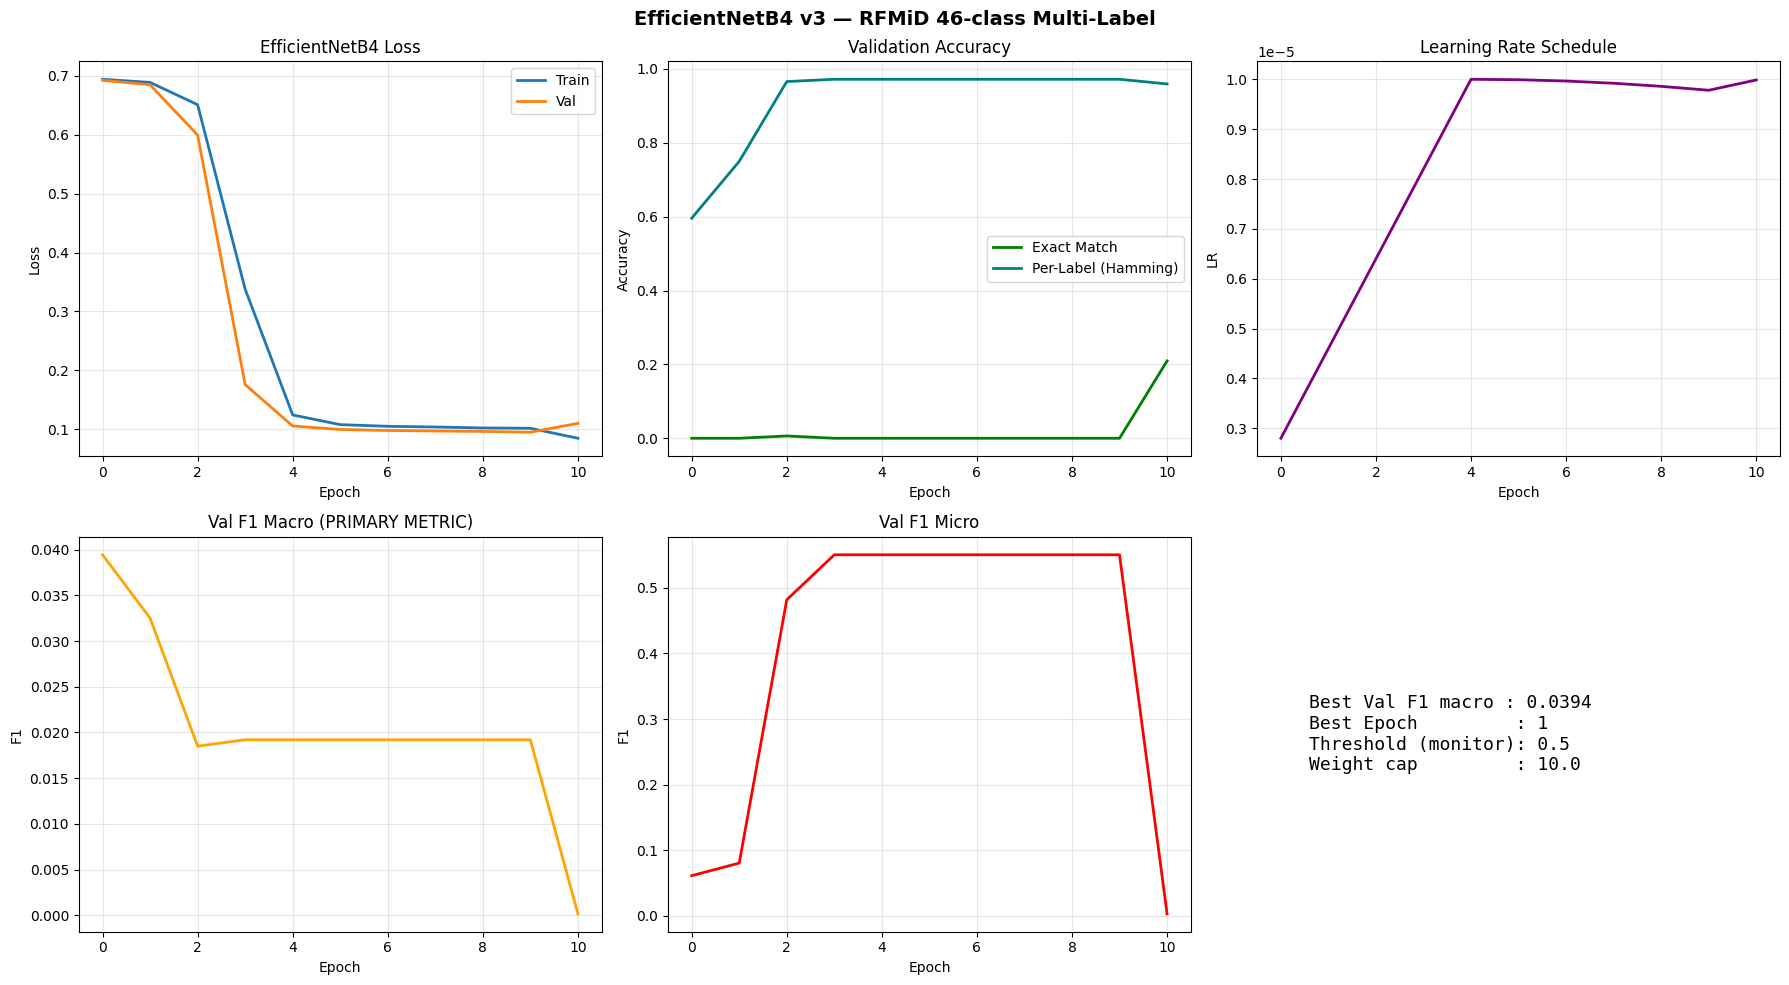

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0,0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0,0].set(xlabel='Epoch', ylabel='Loss', title='EfficientNetB4 Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history['val_exact_acc'], color='green', linewidth=2, label='Exact Match')
axes[0,1].plot(history['val_label_acc'], color='teal',  linewidth=2, label='Per-Label (Hamming)')
axes[0,1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history['val_f1_macro'], color='orange', linewidth=2)
axes[1,0].set(xlabel='Epoch', ylabel='F1', title='Val F1 Macro (PRIMARY METRIC)')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history['val_f1_micro'], color='red', linewidth=2)
axes[1,1].set(xlabel='Epoch', ylabel='F1', title='Val F1 Micro')
axes[1,1].grid(alpha=0.3)

axes[0,2].plot(history['lr'], color='purple', linewidth=2)
axes[0,2].set(xlabel='Epoch', ylabel='LR', title='Learning Rate Schedule')
axes[0,2].grid(alpha=0.3)

axes[1,2].axis('off')
axes[1,2].text(0.1, 0.5,
    f'Best Val F1 macro : {best_f1:.4f}\nBest Epoch         : {best_epoch}\n'
    f'Threshold (monitor): {PRED_THRESHOLD}\nWeight cap         : 10.0',
    fontsize=13, verticalalignment='center', family='monospace')

plt.suptitle('EfficientNetB4 v3 — RFMiD 46-class Multi-Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/efficientnetb4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11b. Threshold Tuning on Validation Set *(Same grid search as ResNet-50)*

The monitoring threshold (0.05) was only used during training to detect learning signal.
Here we do a proper grid search to find the threshold that maximises F1 macro on the
validation set — identical procedure to ResNet-50.

In [14]:
ckpt = torch.load(r'D:\OcuSight\checkpoints\best_efficientnetb4.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"] + 1}  |  Val F1: {ckpt["val_f1"]:.4f}')

model.eval()
all_probs, all_labels_t = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Collecting probs'):
        images = images.to(device, non_blocking=True)
        with autocast(dtype=amp_dtype):
            outputs = model(images)
            probs   = torch.sigmoid(outputs)
        all_probs.append(probs.cpu().float())
        all_labels_t.append(labels.cpu().float())

all_probs    = torch.cat(all_probs).numpy()
all_labels_t = torch.cat(all_labels_t).numpy()

# Extended search range — go lower since capped weights = more conservative outputs
thresholds = np.arange(0.05, 0.55, 0.05)
results    = []

for t in thresholds:
    preds = (all_probs > t).astype(float)
    f1m   = f1_score(all_labels_t, preds, average='macro', zero_division=0)
    results.append((t, f1m))

best_thresh, best_thresh_f1 = max(results, key=lambda x: x[1])

print(f'\nThreshold search results:')
for t, f1m in results:
    marker = ' <-- BEST' if t == best_thresh else ''
    print(f'  threshold={t:.2f}  F1 macro={f1m:.4f}{marker}')

print(f"\nBest Threshold : {best_thresh:.3f}")
print(f"Best Val F1    : {best_thresh_f1:.4f}")

BEST_THRESHOLD = best_thresh
print(f'\nUsing threshold {BEST_THRESHOLD:.2f} for test evaluation')

Loaded best checkpoint from epoch 1  |  Val F1: 0.0394



Threshold search results:
  threshold=0.05  F1 macro=0.0621 <-- BEST
  threshold=0.10  F1 macro=0.0621
  threshold=0.15  F1 macro=0.0621
  threshold=0.20  F1 macro=0.0621
  threshold=0.25  F1 macro=0.0621
  threshold=0.30  F1 macro=0.0621
  threshold=0.35  F1 macro=0.0621
  threshold=0.40  F1 macro=0.0621
  threshold=0.45  F1 macro=0.0621
  threshold=0.50  F1 macro=0.0394

Best Threshold : 0.050
Best Val F1    : 0.0621

Using threshold 0.05 for test evaluation


## 12. Evaluate on Test Set

In [15]:
test_metrics = validate_epoch(
    model, test_loader, val_criterion, device, amp_dtype, threshold=BEST_THRESHOLD
)

print('\n' + '=' * 60)
print('TEST SET RESULTS — EfficientNetB4 v3')
print('=' * 60)
print(f'Test Loss          : {test_metrics["loss"]:.4f}')
print(f'Test Exact Acc     : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc : {test_metrics["per_label_acc"]:.4f}')
print(f'Test F1 macro      : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro      : {test_metrics["f1_micro"]:.4f}')
print(f'Threshold used     : {BEST_THRESHOLD:.2f}')


TEST SET RESULTS — EfficientNetB4 v3
Test Loss          : 0.6924
Test Exact Acc     : 0.0000
Test Per-Label Acc : 0.0399
Test F1 macro      : 0.0606
Test F1 micro      : 0.0768
Threshold used     : 0.05


## 13. Per-Class Performance

In [16]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics['labels'], test_metrics['predictions'], average=None, zero_division=0
)
per_class_df = pd.DataFrame({
    'Disease'  : disease_cols, 'Precision': precision,
    'Recall'   : recall,       'F1-Score' : f1,       'Samples': support,
}).sort_values('F1-Score', ascending=False)

per_class_df.to_csv('outputs/efficientnetb4_per_class_results.csv', index=False)
print('Top 10:')
print(per_class_df.head(10).to_string(index=False))
print('\nBottom 10:')
print(per_class_df.tail(10).to_string(index=False))

Top 10:
     Disease  Precision  Recall  F1-Score  Samples
Disease_Risk   0.790625     1.0  0.883072      506
          DR   0.193750     1.0  0.324607      124
          MH   0.162500     1.0  0.279570      104
         ODC   0.142187     1.0  0.248974       91
        TSLN   0.082812     1.0  0.152958       53
          DN   0.071875     1.0  0.134111       46
         MYA   0.050000     1.0  0.095238       32
        ARMD   0.048438     1.0  0.092399       31
         ODP   0.037500     1.0  0.072289       24
        BRVO   0.035937     1.0  0.069382       23

Bottom 10:
Disease  Precision  Recall  F1-Score  Samples
     CB   0.001563     1.0   0.00312        1
   CRAO   0.000000     0.0   0.00000        0
   PTCR   0.000000     0.0   0.00000        0
    MNF   0.000000     0.0   0.00000        0
    MCA   0.000000     0.0   0.00000        0
     VS   0.000000     0.0   0.00000        0
   BRAO   0.000000     0.0   0.00000        0
    PLQ   0.000000     0.0   0.00000        0
   HP

## 14. Visualize Per-Class Performance

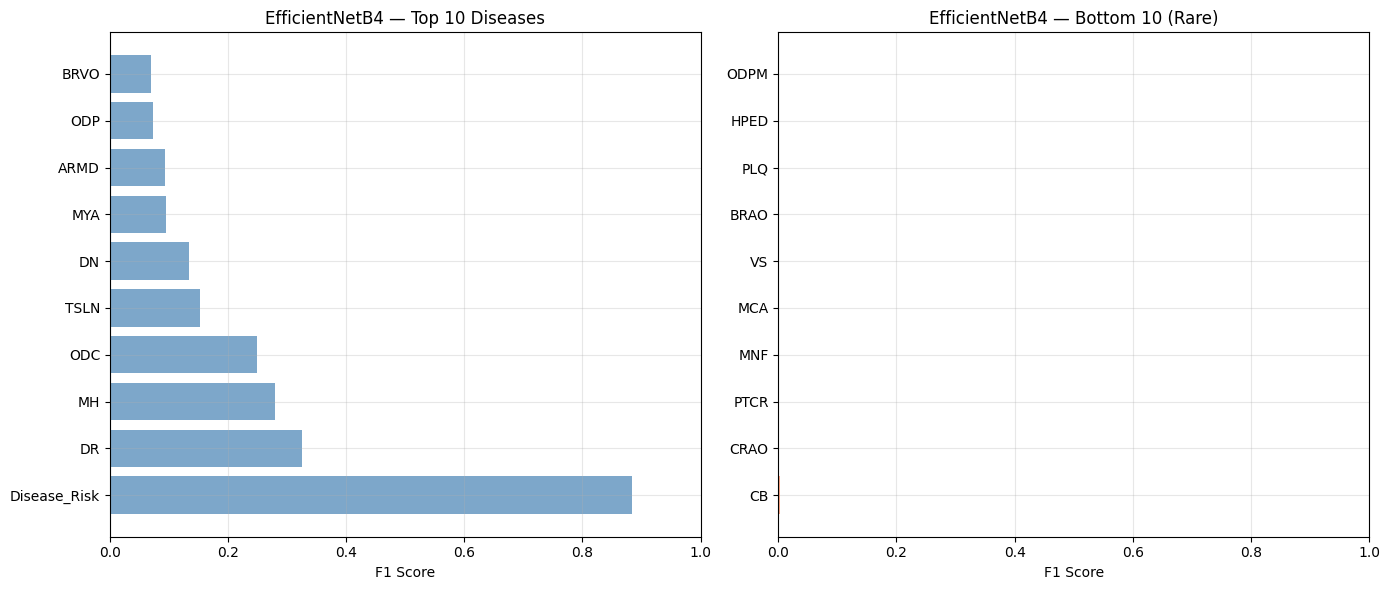

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top10    = per_class_df.head(10)
bottom10 = per_class_df.tail(10)
axes[0].barh(top10['Disease'],    top10['F1-Score'],    color='steelblue', alpha=0.7)
axes[0].set(xlabel='F1 Score', title='EfficientNetB4 — Top 10 Diseases', xlim=(0, 1))
axes[0].grid(alpha=0.3)
axes[1].barh(bottom10['Disease'], bottom10['F1-Score'], color='coral', alpha=0.7)
axes[1].set(xlabel='F1 Score', title='EfficientNetB4 — Bottom 10 (Rare)', xlim=(0, 1))
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/efficientnetb4_per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Side-by-Side Comparison with ResNet-50

Run ResNet-50 notebook first to generate `outputs/training_results.json`.
This cell loads those results and produces a full comparison table for your paper.

In [18]:
resnet_results_path = 'outputs/training_results.json'

if os.path.exists(resnet_results_path):
    with open(resnet_results_path) as f:
        resnet_results = json.load(f)

    comparison = pd.DataFrame({
        'Metric'         : [
            'Test F1 Macro', 'Test F1 Micro', 'Test Exact Acc', 'Test Per-Label Acc',
            'Test Loss', 'Best Val F1 Macro', 'Best Epoch',
            'Total Params (M)', 'Input Size', 'Batch Size',
            'Frozen Layers', 'Frozen Params %', 'Initial LR', 'Weight Cap',
        ],
        'ResNet-50'      : [
            f"{resnet_results['test_f1_macro']:.4f}",
            f"{resnet_results['test_f1_micro']:.4f}",
            f"{resnet_results['test_exact_acc']:.4f}",
            f"{resnet_results['test_label_acc']:.4f}",
            f"{resnet_results['test_loss']:.4f}",
            f"{resnet_results['best_val_f1']:.4f}",
            str(resnet_results['best_epoch']),
            '24.6', '224x224', '32',
            'layer1-3 (3/4)', '~35%', '1e-4', 'None needed',
        ],
        'EfficientNetB4' : [
            f"{test_metrics['f1_macro']:.4f}",
            f"{test_metrics['f1_micro']:.4f}",
            f"{test_metrics['exact_match_acc']:.4f}",
            f"{test_metrics['per_label_acc']:.4f}",
            f"{test_metrics['loss']:.4f}",
            f"{best_f1:.4f}",
            str(best_epoch),
            '19.3', '380x380', '32',
            'features[0-3] (4/9)', '~10%', '3e-5', '10.0',
        ]
    })

    comparison.to_csv('outputs/model_comparison.csv', index=False)
    print('\n' + '=' * 65)
    print('MODEL COMPARISON — ResNet-50 vs EfficientNetB4 on RFMiD')
    print('=' * 65)
    print(comparison.to_string(index=False))
    print('\nSaved to outputs/model_comparison.csv')
else:
    print('ResNet-50 results not found. Run the ResNet-50 notebook first.')
    print('Expected path:', resnet_results_path)


MODEL COMPARISON — ResNet-50 vs EfficientNetB4 on RFMiD
            Metric      ResNet-50      EfficientNetB4
     Test F1 Macro         0.1769              0.0606
     Test F1 Micro         0.6142              0.0768
    Test Exact Acc         0.3859              0.0000
Test Per-Label Acc         0.9717              0.0399
         Test Loss         0.0949              0.6924
 Best Val F1 Macro         0.1351              0.0394
        Best Epoch             18                   1
  Total Params (M)           24.6                19.3
        Input Size        224x224             380x380
        Batch Size             32                  32
     Frozen Layers layer1-3 (3/4) features[0-3] (4/9)
   Frozen Params %           ~35%                ~10%
        Initial LR           1e-4                3e-5
        Weight Cap    None needed                10.0

Saved to outputs/model_comparison.csv


## 16. Save Results

In [19]:
results = {
    'model'          : 'EfficientNetB4_v5',
    'best_val_f1'    : best_f1,
    'best_epoch'     : best_epoch,
    'best_threshold' : float(BEST_THRESHOLD),
    'test_loss'      : float(test_metrics['loss']),
    'test_exact_acc' : float(test_metrics['exact_match_acc']),
    'test_label_acc' : float(test_metrics['per_label_acc']),
    'test_f1_macro'  : float(test_metrics['f1_macro']),
    'test_f1_micro'  : float(test_metrics['f1_micro']),
    'fixes_applied'  : {
        'frozen_blocks'   : 'features[0-3] only (was 0-6)',
        'batchnorm_eval'  : 'removed (was forcing eval during freeze)',
        'initial_lr'      : '3e-5 (was 1e-4)',
        'patience'        : '10 (was 5)',
        'monitor_thresh'  : '0.05 (was 0.3)',
        'weight_cap'      : '10.0 (was uncapped — caused output collapse)',
    },
    'history': {
        'train_loss'    : history['train_loss'],   'val_loss'      : history['val_loss'],
        'val_exact_acc' : history['val_exact_acc'], 'val_label_acc' : history['val_label_acc'],
        'val_f1_macro'  : history['val_f1_macro'],  'val_f1_micro'  : history['val_f1_micro'],
    },
    'hardware': {
        'gpu'            : hw.gpu_name if device.type == 'cuda' else 'CPU',
        'batch_size'     : BATCH_SIZE,
        'mixed_precision': 'BF16' if use_bf16 else 'FP16',
        'input_size'     : INPUT_SIZE,
    },
}

with open('outputs/efficientnetb4_training_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to outputs/efficientnetb4_training_results.json')

Results saved to outputs/efficientnetb4_training_results.json


## 17. Summary Report

In [20]:
print('=' * 60)
print('EFFICIENTNET-B4 v5 TRAINING SUMMARY')
print('=' * 60)
print(f'Dataset      : {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test  |  {num_classes} classes')
print(f'Model        : EfficientNetB4  ({total_params:,} params, {total_params*4/1024/1024:.1f} MB)')
print(f'Epochs run   : {len(history["train_loss"])}')
print(f'Precision    : {"BF16" if use_bf16 else "FP16"}')
print(f'Threshold    : {BEST_THRESHOLD:.2f} (tuned on val set)')
print(f'Input size   : {INPUT_SIZE}x{INPUT_SIZE}')
print(f'Weight cap   : 10.0 (key fix for output collapse)')
print(f'\nBest Val F1 macro  : {best_f1:.4f}  (epoch {best_epoch})')
print(f'Test F1 macro      : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro      : {test_metrics["f1_micro"]:.4f}')
print(f'Test Exact Acc     : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc : {test_metrics["per_label_acc"]:.4f}')
if device.type == 'cuda':
    print(f'\nGPU : {hw.gpu_name}  ({hw.vram_total:.1f} GB VRAM)')
print('\n' + '=' * 60)

EFFICIENTNET-B4 v5 TRAINING SUMMARY
Dataset      : 1920 train / 640 val / 640 test  |  46 classes
Model        : EfficientNetB4  (18,490,230 params, 70.5 MB)
Epochs run   : 11
Precision    : BF16
Threshold    : 0.05 (tuned on val set)
Input size   : 380x380
Weight cap   : 10.0 (key fix for output collapse)

Best Val F1 macro  : 0.0394  (epoch 1)
Test F1 macro      : 0.0606
Test F1 micro      : 0.0768
Test Exact Acc     : 0.0000
Test Per-Label Acc : 0.0399

GPU : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)



## 18. Inference Helper

In [21]:
def predict_image(image_path: str, model: nn.Module, device, amp_dtype, threshold=None):
    """Return predicted diseases and top probabilities for one image."""
    if threshold is None:
        threshold = BEST_THRESHOLD
    tensor = OptimizedTransforms.get_val_transform()(Image.open(image_path).convert('RGB'))
    tensor = tensor.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with autocast(dtype=amp_dtype):
            probs = torch.sigmoid(model(tensor)).cpu().numpy()[0]
    positive  = [disease_cols[i] for i, p in enumerate(probs) if p > threshold]
    top_probs = {disease_cols[i]: float(probs[i]) for i in range(len(probs)) if probs[i] > threshold}
    return positive, top_probs

print('predict_image() is ready.')
print(f'Default threshold: {BEST_THRESHOLD:.2f} (tuned on val set)')
print('Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)')
# diseases, probs = predict_image('data/rfmid/images/test/1.png', model, device, amp_dtype)
# print(diseases, probs)

predict_image() is ready.
Default threshold: 0.05 (tuned on val set)
Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)
